# Activation diameter of NorESM/OsloAero aerosol modes at observational stations

**Scientific question.** For each aerosol mode in NorESM/OsloAero, what is the
*activation radius* — the dry radius above which a given fraction of particles
activates into cloud droplets — and how does the number-weighted **bulk
activation diameter** vary across observational stations?

The activation radius is recovered from the lognormal mode parameters and the
model-reported activated fraction. For a lognormal mode with number median
radius `NMR` and geometric standard deviation `SIGMA`, the radius exceeded by a
fraction `p` of the particles is

$$R_\mathrm{act} = \exp\!\big(\ln \mathrm{NMR} + \ln \mathrm{SIGMA}\cdot\Phi^{-1}(1-p)\big),$$

where `p = NACT_FRAC / 100` is the activated fraction and `Phi^-1` is the
inverse standard-normal CDF (`scipy.special.ndtri`).

**Endpoints are physical.** `p = 1` (everything activates) drives the inverse
CDF to `-inf` and `R_act -> 0`; `p = 0` (nothing activates) drives it to `+inf`
and `R_act -> inf`. Both are degenerate for a *diameter* — a mode that fully
activates has no meaningful activation size, and one that never activates has
none either. Cells at or near these limits are therefore dropped before the
weighted diameter is formed (see Section 4).

**Input conventions** (confirmed during debugging of this dataset):

| field | meaning | units |
|---|---|---|
| `NMR{i:02d}` | number median radius of mode *i* | nm (linear, **not** log-space) |
| `SIGMA{i:02d}` | geometric standard deviation $\sigma_g$ | – (use `log(SIGMA)`) |
| `NACT_FRAC{i:02d}` | activated fraction of mode *i* | **percent** (0–100) |
| `NCONC{i:02d}` | number concentration of mode *i* | cm⁻³ (weight) |
| `FREQL` | liquid-cloud frequency | – (0–1) |


## 1 · Setup and configuration

All tunable constants live here so the rest of the notebook reads as a single
pass. `MODE_INDICES` are the activating NorESM/OsloAero modes; `FREQL_THRESH`
is the liquid-cloud frequency cut applied to every field.

In [122]:
import numpy as np
import xarray as xr
import scipy.special as sp
import matplotlib.pyplot as plt

import PeterChurchillFunctions as Function  # repo conventions / shared helpers

# ----------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------
NOR_PATH = (
    "/share/sabl0586/all_stations_NorESM_OsloAero_"
    "prcp2szdst_f19_f19_noresmv211_corr_ilevall_levs_4Peter.nc"
)
MODE_INDICES = [1, 2, 4, 5, 6, 7, 8, 9, 10, 12, 14]  # activating modes
FREQL_THRESH = 0.8        # liquid-cloud frequency cut
FRAC_LO      = 0        # drop modes activated <1%  (R_act -> inf side)
FRAC_HI      = 100       # drop modes activated >99% (R_act -> 0  side)
STATION      = "SMR-II"   # reference station for the single-station figures
OUTDIR       = "."        # where figures are written

ds = xr.open_dataset(NOR_PATH, chunks={})
ds

<xarray.Dataset> Size: 2GB
Dimensions:             (time: 8761, station: 15, lev: 32, ilev: 33)
Coordinates:
  * time                (time) datetime64[ns] 70kB 2012-01-02 ... 2015-01-01
  * station             (station) <U8 480B 'ZEP' 'SMR-II' ... 'Izana' 'Maldives'
  * lev                 (lev) float64 256B 3.643 7.595 14.36 ... 976.3 992.6
  * ilev                (ilev) float64 264B 2.255 5.032 10.16 ... 985.1 1e+03
Data variables: (12/275)
    ABSVIS              (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>
    ACTNI               (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>
    ACTNL               (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>
    ACTREI              (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>
    ACTREL              (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>
    AOD_VIS             (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>
    ...                  ...
    isoprene            (station, time, lev) float32 17MB dask.array<chunksize=(15, 8761, 32), meta=np.ndarray>
    monoterp            (station, time, lev) float32 17MB dask.array<chunksize=(15, 8761, 32), meta=np.ndarray>
    TOT_ICLD_VISTAU_s   (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>
    TOT_CLD_VISTAU_s    (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>
    optical_depth       (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>
    transmittance       (station, time) float32 526kB dask.array<chunksize=(15, 8761), meta=np.ndarray>

## 2 · Activation radius per mode

`activation_radius` applies the three input corrections — `log(NMR)`,
`log(SIGMA)`, and `NACT_FRAC/100` — and returns the per-mode activation radius
in nm. It is lazy (dask-parallelised through `apply_ufunc`) so it can run on a
single station or the full station stack without loading everything into
memory.

In [123]:
def activation_radius(dset, i, frac_lo=1.0, frac_hi=99.0):   # percent scale
    """Activation radius of mode *i* for an xarray dataset, in nm.

    Parameters
    ----------
    dset : xarray.Dataset
        Must contain ``NMR{i:02d}``, ``SIGMA{i:02d}`` and ``NACT_FRAC{i:02d}``.
    i : int
        Mode index.

    Returns
    -------
    xarray.DataArray
        Activation radius in nm. ``p = 1`` gives 0, ``p = 0`` gives inf
        (both are masked downstream).
    """
    frac  = dset[f"NACT_FRAC{i:02d}"]
    p     = frac.where((frac > frac_lo) & (frac < frac_hi)) / 100.0
    mu    = np.log(dset[f"NMR{i:02d}"])
    sigma = np.log(dset[f"SIGMA{i:02d}"])
    z = xr.apply_ufunc(sp.ndtri, 1 - p,
                       dask="parallelized", output_dtypes=[float])
    return np.exp(mu + sigma * z)              # nm

## 3 · Single-station activation radius (reference: SMR-II)

Compute the per-mode activation radius at the reference station, mask to liquid
cloud, and drop the degenerate endpoints. Zeros (`R_act = 0`, full activation)
and infs (`R_act = inf`, no activation) are both removed here: `np.isfinite`
drops inf/NaN, and the explicit `> 0` drops the full-activation floor. This
matches the outlier handling used for the weighted diameter in Section 4, so
the per-mode summary below is directly comparable.

In [124]:
dss = ds.sel(station=STATION)

# Stack all modes along a 'mode' dimension
R_act = xr.concat(
    [activation_radius(dss, i, frac_lo = FRAC_LO, frac_hi = FRAC_HI) for i in MODE_INDICES],
    dim=xr.DataArray(MODE_INDICES, dims="mode", name="mode"),
)
R_act.name = "R_act"
R_act.attrs.update(units="nm", long_name="activation radius")

# Mask: liquid cloud only, then drop both degenerate endpoints.
cloud_mask = dss["FREQL"] > FREQL_THRESH
R_clean = R_act.where(cloud_mask)
R_clean = R_clean.where(np.isfinite(R_clean))   # drop inf (no activation) + NaN
R_clean = R_clean.where(R_clean > 0)            # drop 0 (full activation) floor
R_clean = R_clean.compute()                     # single station -> small enough


def mode_values(m):
    """1-D numpy array of finite activation radii (nm) for mode *m*."""
    a = R_clean.sel(mode=m).values.ravel()
    return a[np.isfinite(a)]

### Per-mode numeric summary

In [125]:
print(f"Activation radius summary at {STATION}  (nm, cloud & finite only)")
print(f"{'mode':>5} {'n':>10} {'min':>10} {'median':>10} {'mean':>10} {'max':>10}")
for m in MODE_INDICES:
    v = mode_values(m)
    if v.size:
        print(f"{m:>5} {v.size:>10d} {v.min():>10.2f} "
              f"{np.median(v):>10.2f} {v.mean():>10.2f} {v.max():>10.2f}")
    else:
        print(f"{m:>5} {0:>10d} {'--':>10} {'--':>10} {'--':>10} {'--':>10}")

Activation radius summary at SMR-II  (nm, cloud & finite only)
 mode          n        min     median       mean        max
    1      11125      17.72      60.03      60.96     139.82
    2      11081       1.30      58.14      73.24     268.22
    4      10964       3.44      41.82      40.37     161.46
    5      10975       7.09      40.30      40.86     125.89
    6      11068      19.40      56.21      56.59     167.40
    7      11109      16.07      97.78     142.86    1737.69
    8      11008       1.22      31.48      30.16     100.38
    9       6336      16.93      37.53      37.72      93.98
   10         85      61.32      61.98      64.21      93.69
   12       4854      14.83      41.10      42.28     189.96
   14       6271      26.08      75.79      76.41     191.20


### Figure 1 — Activation radius distribution per mode

A box plot across modes (log y-axis, since the radii span orders of magnitude),
followed by a per-mode histogram grid on log-spaced bins.

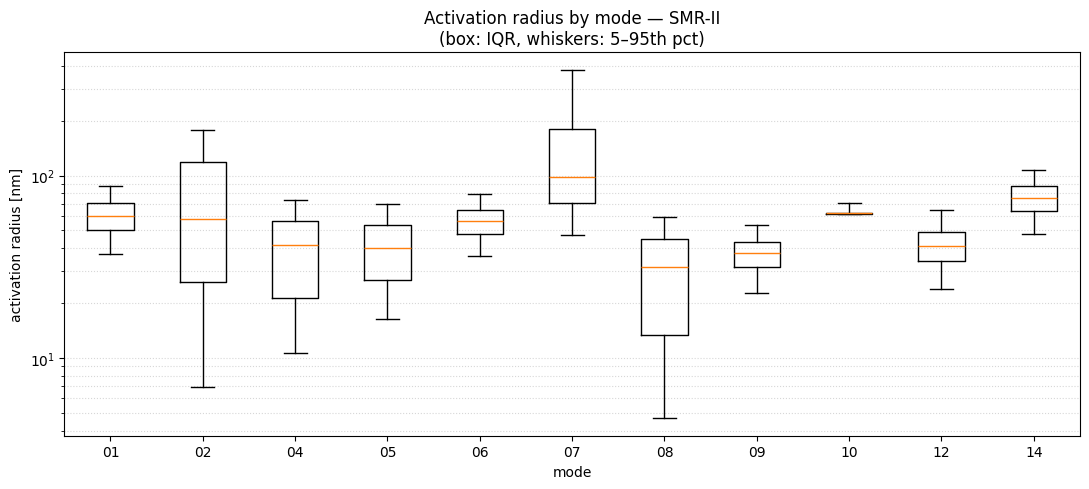

In [126]:
# 1a. Box plot across modes
fig, ax = plt.subplots(figsize=(11, 5))
data_box = [mode_values(m) for m in MODE_INDICES]
data_box = [v if v.size else np.array([np.nan]) for v in data_box]
ax.boxplot(data_box, tick_labels=[f"{m:02d}" for m in MODE_INDICES],
           showfliers=False, whis=(5, 95))
ax.set_yscale("log")
ax.set_xlabel("mode")
ax.set_ylabel("activation radius [nm]")
ax.set_title(f"Activation radius by mode — {STATION}\n"
             f"(box: IQR, whiskers: 5–95th pct)")
ax.grid(True, which="both", axis="y", ls=":", alpha=0.5)
fig.tight_layout()
fig.savefig(f"{OUTDIR}/Ract_box_by_mode_{STATION}.png", dpi=150)
plt.show()

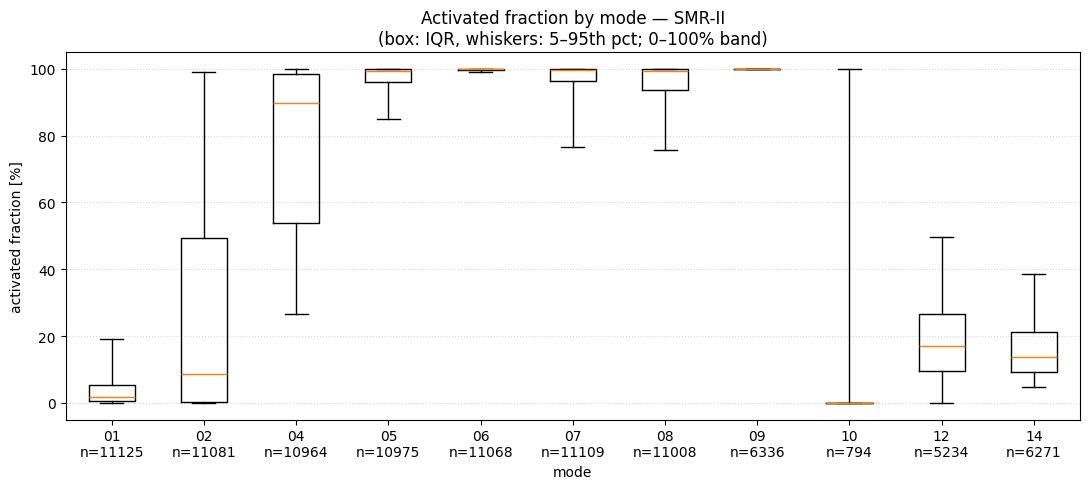

In [127]:
STATION       = "SMR-II"
MODE_INDICES  = [1, 2, 4, 5, 6, 7, 8, 9, 10, 12, 14]

mask = (ds['FREQL'].sel(station=STATION) > 0.8)

def mode_values(m):
    a = ds[f'NACT_FRAC{m:02d}'].sel(station=STATION).where(mask).compute()
    v = a.values.ravel()
    v = v[np.isfinite(v)]
    return v[(v > FRAC_LO) & (v < FRAC_HI)]

fig, ax = plt.subplots(figsize=(11, 5))
data_box = [mode_values(m) for m in MODE_INDICES]
counts   = [v.size for v in data_box]
data_box = [v if v.size else np.array([np.nan]) for v in data_box]

ax.boxplot(data_box, tick_labels=[f"{m:02d}" for m in MODE_INDICES],
           showfliers=False, whis=(5, 95))
ax.set_xlabel("mode")
ax.set_ylabel("activated fraction [%]")
ax.set_title(f"Activated fraction by mode — {STATION}\n"
             f"(box: IQR, whiskers: 5–95th pct; {FRAC_LO:.0f}–{FRAC_HI:.0f}% band)")
ax.grid(True, axis="y", ls=":", alpha=0.5)

# put n= as a second line under each mode tick label
ax.set_xticklabels([f"{m:02d}\nn={n}" for m, n in zip(MODE_INDICES, counts)])

fig.tight_layout()
fig.savefig(f"{OUTDIR}/NACT_FRAC_box_by_mode_{STATION}.png", dpi=150)
plt.show()

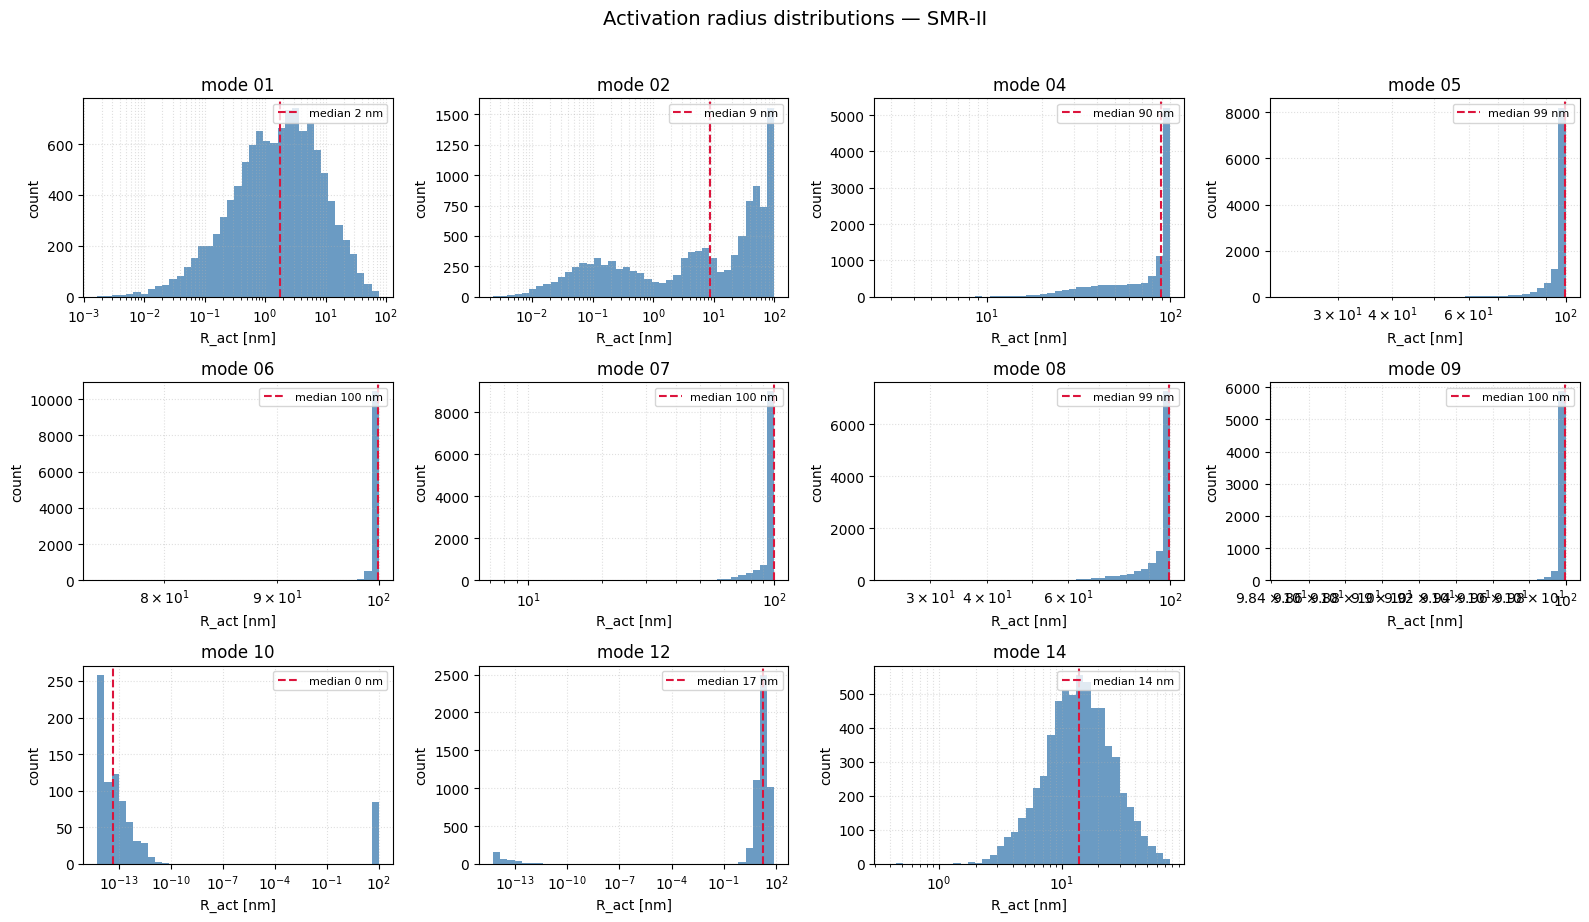

In [128]:
# 1b. Histogram grid (one panel per mode, log-spaced bins)
ncol = 4
nrow = int(np.ceil(len(MODE_INDICES) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3 * nrow))
axes = np.atleast_1d(axes).ravel()
for ax, m in zip(axes, MODE_INDICES):
    v = mode_values(m)
    if v.size:
        bins = np.logspace(np.log10(v.min()), np.log10(v.max()), 40)
        ax.hist(v, bins=bins, color="steelblue", alpha=0.8)
        ax.set_xscale("log")
        ax.axvline(np.median(v), color="crimson", ls="--", lw=1.5,
                   label=f"median {np.median(v):.0f} nm")
        ax.legend(fontsize=8, loc="upper right")
    ax.set_title(f"mode {m:02d}")
    ax.set_xlabel("R_act [nm]")
    ax.set_ylabel("count")
    ax.grid(True, which="both", ls=":", alpha=0.4)
for ax in axes[len(MODE_INDICES):]:          # hide unused panels
    ax.set_visible(False)
fig.suptitle(f"Activation radius distributions — {STATION}", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(f"{OUTDIR}/Ract_hist_grid_{STATION}.png", dpi=150, bbox_inches="tight")
plt.show()

### Figure 2 — Vertical profile vs pressure level

Median activation radius at each pressure level (reducing over all other
dimensions), one line per mode. Skipped automatically if the station selection
has no `lev` dimension.

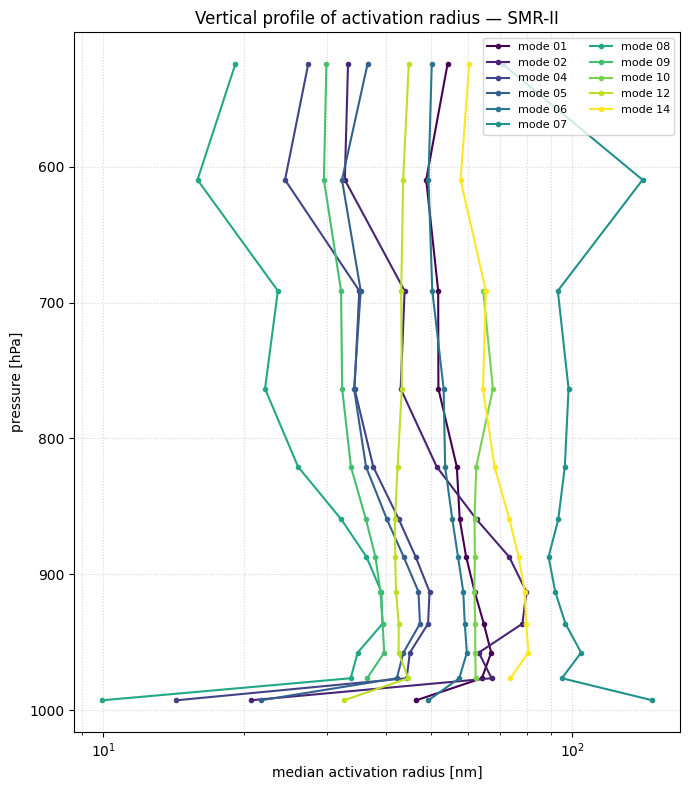

In [129]:
if "lev" in R_clean.dims:
    other = [d for d in R_clean.dims if d not in ("mode", "lev")]
    R_prof = R_clean.median(dim=other)                       # dims: (mode, lev)
    lev = dss["lev"].values if "lev" in dss else R_clean["lev"].values

    fig, ax = plt.subplots(figsize=(7, 8))
    cmap = plt.cm.viridis(np.linspace(0, 1, len(MODE_INDICES)))
    for c, m in zip(cmap, MODE_INDICES):
        ax.plot(R_prof.sel(mode=m).values, lev, "-o", ms=3,
                color=c, label=f"mode {m:02d}")
    ax.set_xscale("log")
    ax.invert_yaxis()                                        # surface at bottom
    ax.set_xlabel("median activation radius [nm]")
    ax.set_ylabel("pressure [hPa]")
    ax.set_title(f"Vertical profile of activation radius — {STATION}")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, which="both", ls=":", alpha=0.5)
    fig.tight_layout()
    fig.savefig(f"{OUTDIR}/Ract_profile_{STATION}.png", dpi=150)
    plt.show()
else:
    print("No 'lev' dimension found — skipping vertical profile figure.")

### Figure 3 — Time series

Median activation radius through time (reducing over any non-time, non-mode
dimensions), one line per mode.

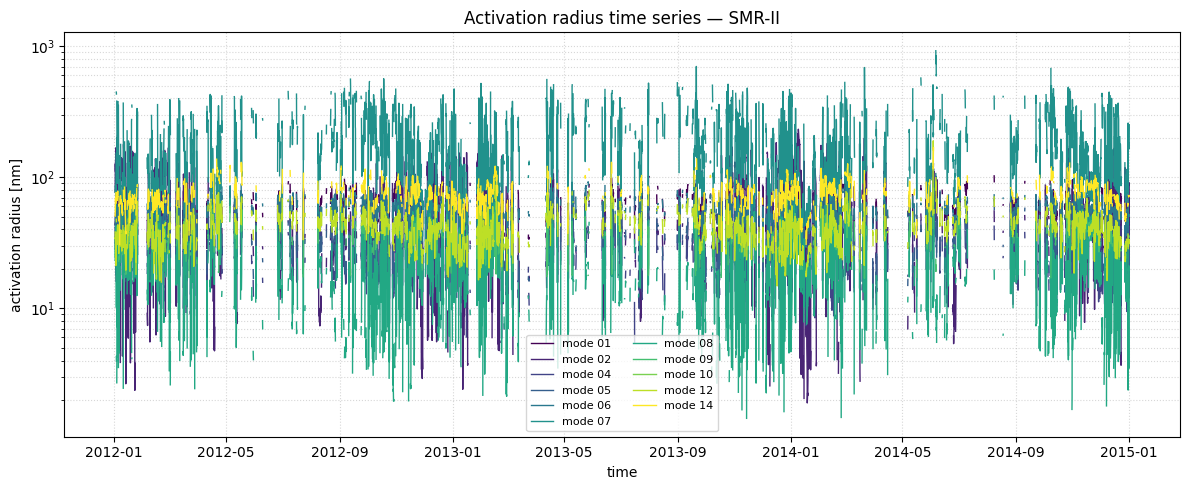

In [130]:
if "time" in R_clean.dims:
    reduce_dims = [d for d in R_clean.dims if d not in ("mode", "time")]
    R_ts = R_clean.median(dim=reduce_dims) if reduce_dims else R_clean

    fig, ax = plt.subplots(figsize=(12, 5))
    cmap = plt.cm.viridis(np.linspace(0, 1, len(MODE_INDICES)))
    for c, m in zip(cmap, MODE_INDICES):
        ax.plot(R_ts["time"].values, R_ts.sel(mode=m).values,
                "-", lw=1, color=c, label=f"mode {m:02d}")
    ax.set_yscale("log")
    ax.set_xlabel("time")
    ax.set_ylabel("activation radius [nm]")
    ax.set_title(f"Activation radius time series — {STATION}")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, which="both", ls=":", alpha=0.5)
    fig.tight_layout()
    fig.savefig(f"{OUTDIR}/Ract_timeseries_{STATION}.png", dpi=150)
    plt.show()
else:
    print("No 'time' dimension found — skipping time-series figure.")

## 4 · Number-weighted bulk activation diameter

The bulk activation **diameter** combines the modes into one number per cell,
weighting each mode's diameter (`2 * R_act`) by its number concentration
`NCONC`:

$$D_\mathrm{weighted} = \frac{\sum_i \mathrm{NCONC}_i \cdot 2 R_{\mathrm{act},i}}
                              {\sum_i \mathrm{NCONC}_i}.$$

**Outlier handling (fraction-band guard).** Before the radius is even computed,
modes whose activated fraction falls outside `(FRAC_LO, FRAC_HI)` are nulled
out. This removes both degenerate limits *and* the near-degenerate tail
(e.g. 99.5% activated), which would otherwise produce a finite-but-meaningless
radius that drags the weighted mean. Because the null propagates from the
radius into `NCONC.where(np.isfinite(D))`, each excluded mode is dropped
consistently from **both** the numerator and the denominator.

In [131]:
def weighted_Dact_for_station(station, frac_lo=1.0, frac_hi=99.0):
    """Number-weighted bulk activation diameter [nm] for one station.

    Modes with activated fraction <= ``frac_lo`` or >= ``frac_hi`` are dropped
    per cell (fraction-band guard) so degenerate / near-degenerate activation
    radii never enter the weighted mean.

    Parameters
    ----------
    station : hashable
        Value to select along the ``station`` dimension.
    frac_lo, frac_hi : float
        Lower / upper activated-fraction bounds (percent, 0–100).

    Returns
    -------
    numpy.ndarray
        1-D array of finite weighted diameters (nm); inf/NaN removed.
    """
    dss = ds.sel(station=station)
    
    def _radius(i):
        frac  = dss[f"NACT_FRAC{i:02d}"]                        # percent (0–100)
        p     = frac.where((frac > frac_lo) & (frac < frac_hi)) / 100.0  # band, then ->fraction
        mu    = np.log(dss[f"NMR{i:02d}"])
        sigma = np.log(dss[f"SIGMA{i:02d}"])
        z = xr.apply_ufunc(sp.ndtri, 1 - p,
                           dask="parallelized", output_dtypes=[float])
        return np.exp(mu + sigma * z)

    R = xr.concat([_radius(i) for i in MODE_INDICES],
                  dim=xr.DataArray(MODE_INDICES, dims="mode", name="mode"))

    # cloud mask; finite + >0 are redundant after the band guard but kept safe
    R = R.where(dss["FREQL"] > FREQL_THRESH)
    R = R.where(np.isfinite(R))
    R = R.where(R > 0)

    NCONC = xr.concat([dss[f"NCONC{i:02d}"] for i in MODE_INDICES],
                      dim=xr.DataArray(MODE_INDICES, dims="mode", name="mode"))

    D  = 2.0 * R                                  # diameter per mode [nm]
    Nw = NCONC.where(np.isfinite(D))              # null weight on excluded modes
    numer = (Nw * D).sum(dim="mode", skipna=True)
    denom = Nw.sum(dim="mode", skipna=True)
    Dw = (numer / denom.where(denom > 0)).compute()

    arr = Dw.values.ravel()
    return arr[np.isfinite(arr)]

### Reference station

Weighted diameter at `STATION`, with a distribution figure. Positive values are
histogrammed on log bins; the (now rare, post-guard) exact-zero fraction is
annotated separately rather than forced onto a log axis.

In [132]:
dw = weighted_Dact_for_station(STATION, frac_lo=FRAC_LO, frac_hi=FRAC_HI)
print(f"D_act_weighted at {STATION} (nm): n={dw.size}  min={dw.min():.2f}  "
      f"median={np.median(dw):.2f}  mean={dw.mean():.2f}  max={dw.max():.2f}")

D_act_weighted at SMR-II (nm): n=11125  min=28.42  median=119.97  mean=118.82  max=286.96


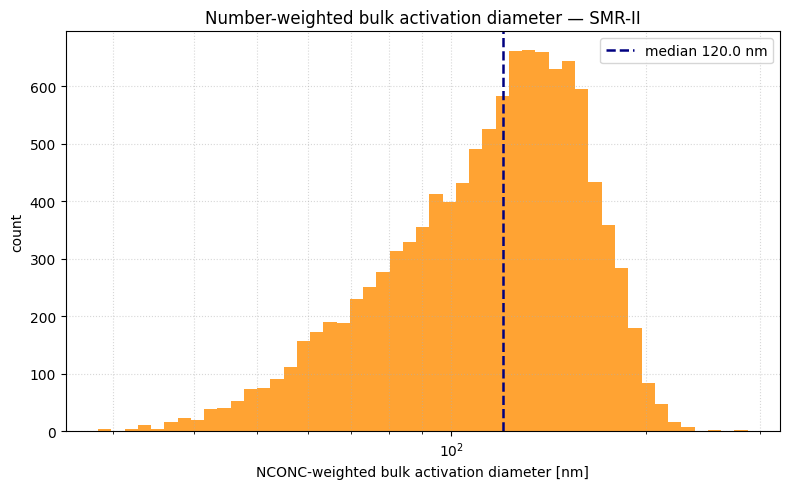

In [133]:
fig, ax = plt.subplots(figsize=(8, 5))
pos = dw[dw > 0]
n_zero = int(np.sum(dw == 0))
if pos.size:
    bins = np.logspace(np.log10(pos.min()), np.log10(pos.max()), 50)
    ax.hist(pos, bins=bins, color="darkorange", alpha=0.8)
    ax.set_xscale("log")
    ax.axvline(np.median(dw), color="navy", ls="--", lw=1.8,
               label=f"median {np.median(dw):.1f} nm")
if n_zero:
    ax.text(0.03, 0.97, f"fully activated (D=0): {n_zero/dw.size:.1%}",
            transform=ax.transAxes, va="top", ha="left", fontsize=9,
            bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))
ax.set_xlabel("NCONC-weighted bulk activation diameter [nm]")
ax.set_ylabel("count")
ax.set_title(f"Number-weighted bulk activation diameter — {STATION}")
ax.legend()
ax.grid(True, which="both", ls=":", alpha=0.5)
fig.tight_layout()
fig.savefig(f"{OUTDIR}/Dact_weighted_{STATION}.png", dpi=150)
plt.show()

## 5 · Weighted activation diameter across all stations

Apply the weighted-diameter calculation to every station. Stations missing a
required field are skipped with a note rather than aborting the loop.

In [134]:
stations = list(ds["station"].values)
Dact_by_station = {}
for st in stations:
    try:
        Dact_by_station[st] = weighted_Dact_for_station(st, frac_lo=FRAC_LO, frac_hi=FRAC_HI)
        v = Dact_by_station[st]
        print(f"{str(st):>12}: n={v.size:>7d}  median={np.median(v):7.2f} nm"
              if v.size else f"{str(st):>12}: no valid points")
    except KeyError as e:
        print(f"{str(st):>12}: skipped (missing {e})")
        Dact_by_station[st] = np.array([])

         ZEP: n=  21172  median=  75.41 nm
      SMR-II: n=  11125  median= 119.97 nm
        ATTO: n=   2630  median= 199.76 nm
         MHD: n=  10454  median= 103.60 nm
         SGP: n=   1326  median= 127.24 nm
         CHC: n=  24759  median= 186.60 nm
      BIR-II: n=   9308  median= 110.21 nm
         PAL: n=  12323  median= 110.96 nm
    Vavihill: n=   6524  median= 115.64 nm
         JFJ: n=  10437  median= 107.74 nm
         FKL: n=    537  median= 122.29 nm
     SMEAR-I: n=  13804  median= 110.17 nm
      Villum: n=   7727  median=  69.37 nm
       Izana: n=   2214  median= 122.32 nm
    Maldives: n=    614  median= 125.07 nm


### Figure 4 — Per-station histogram grid

Shared log bins across all stations for cross-station comparability. Each panel
annotates the fraction of fully-activated (`D = 0`) cells.

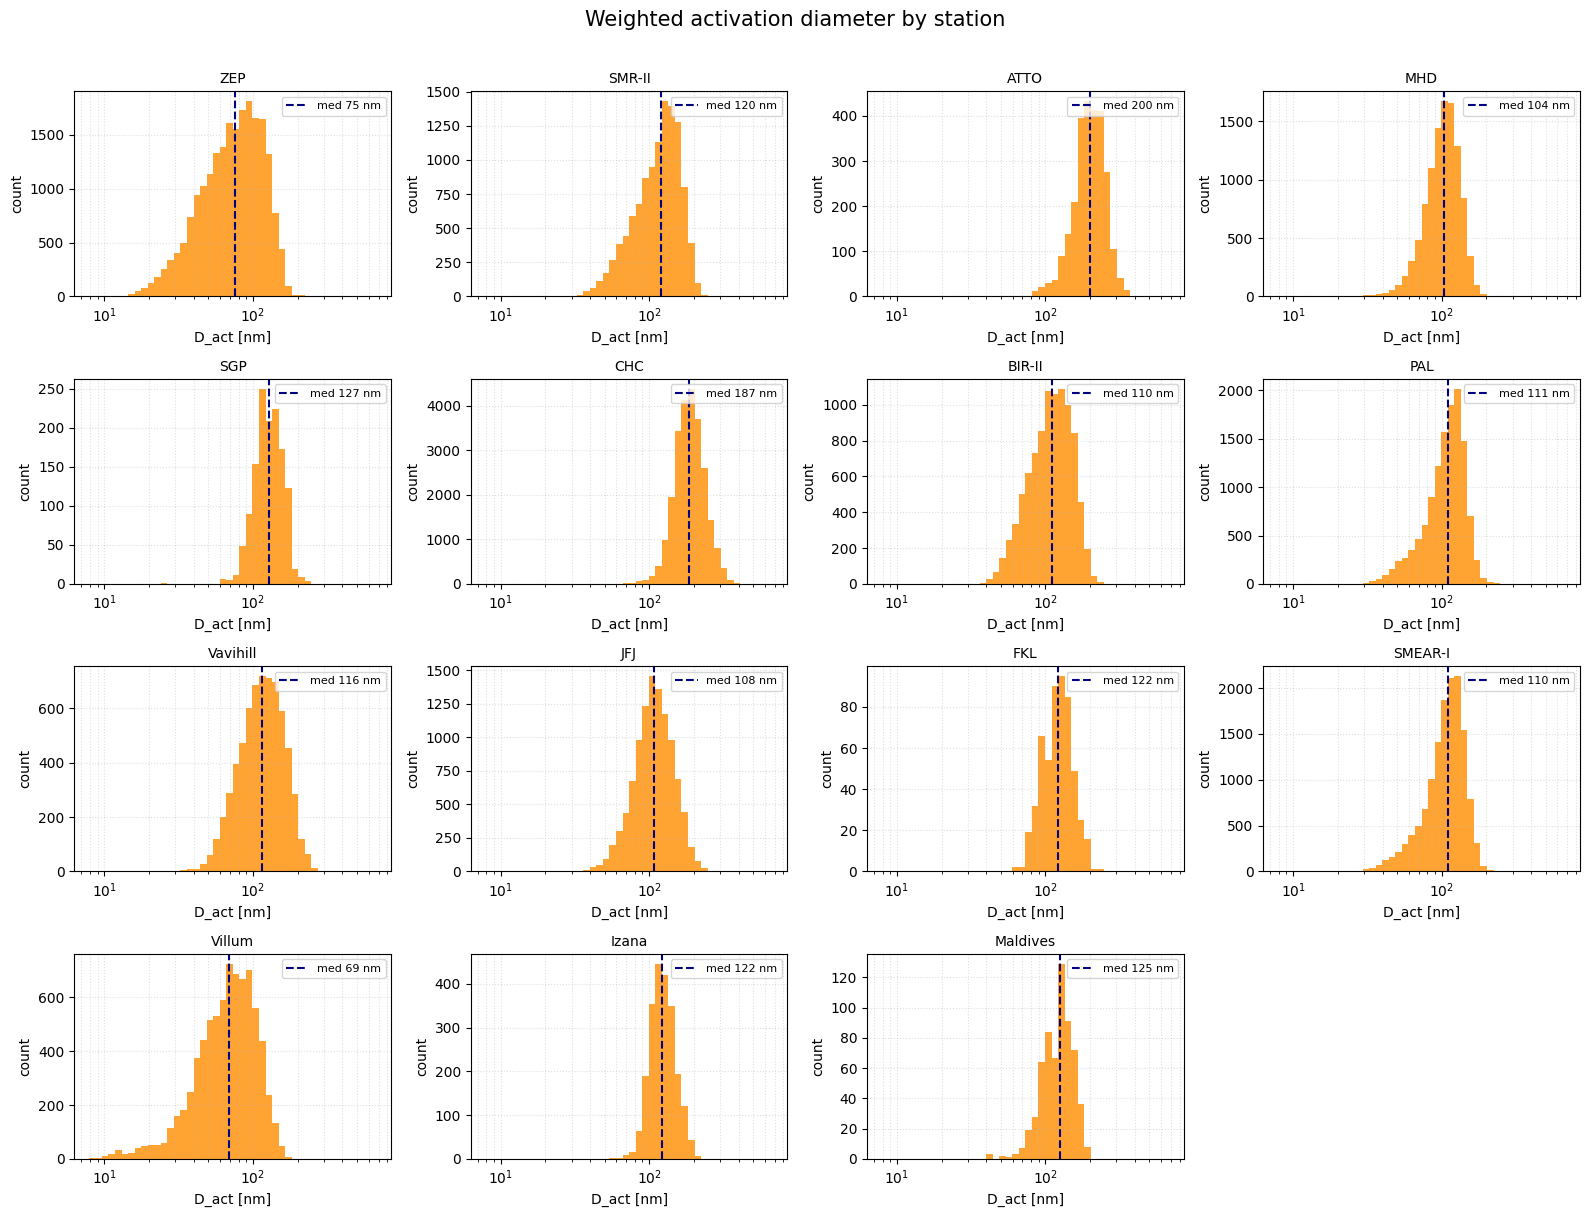

In [135]:
stations_plot = [s for s in stations if Dact_by_station[s].size]
ncol = 4
nrow = int(np.ceil(len(stations_plot) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3 * nrow))
axes = np.atleast_1d(axes).ravel()

# shared log bins across all stations for comparability
allpos = np.concatenate([Dact_by_station[s][Dact_by_station[s] > 0]
                         for s in stations_plot])
bins = np.logspace(np.log10(allpos.min()), np.log10(allpos.max()), 45)

for ax, st in zip(axes, stations_plot):
    v = Dact_by_station[st]
    pos = v[v > 0]
    n_zero = int(np.sum(v == 0))
    if pos.size:
        ax.hist(pos, bins=bins, color="darkorange", alpha=0.8)
        ax.set_xscale("log")
        ax.axvline(np.median(v), color="navy", ls="--", lw=1.5,
                   label=f"med {np.median(v):.0f} nm")
        ax.legend(fontsize=8, loc="upper right")
    if n_zero:
        ax.text(0.03, 0.97, f"D=0: {n_zero/v.size:.0%}",
                transform=ax.transAxes, va="top", ha="left", fontsize=8,
                bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))
    ax.set_title(str(st), fontsize=10)
    ax.set_xlabel("D_act [nm]")
    ax.set_ylabel("count")
    ax.grid(True, which="both", ls=":", alpha=0.4)
for ax in axes[len(stations_plot):]:         # hide unused panels
    ax.set_visible(False)
fig.suptitle("Weighted activation diameter by station", y=1.01, fontsize=15)
fig.tight_layout()
fig.savefig(f"{OUTDIR}/Dact_weighted_by_station.png", dpi=150, bbox_inches="tight")
plt.show()

### Cross-station median summary

A single ranked view of the median weighted activation diameter per station.

In [136]:
medians = {str(s): float(np.median(v))
           for s, v in Dact_by_station.items() if v.size}
for name, med in sorted(medians.items(), key=lambda kv: kv[1]):
    print(f"{name:>12}: {med:7.2f} nm")

      Villum:   69.37 nm
         ZEP:   75.41 nm
         MHD:  103.60 nm
         JFJ:  107.74 nm
     SMEAR-I:  110.17 nm
      BIR-II:  110.21 nm
         PAL:  110.96 nm
    Vavihill:  115.64 nm
      SMR-II:  119.97 nm
         FKL:  122.29 nm
       Izana:  122.32 nm
    Maldives:  125.07 nm
         SGP:  127.24 nm
         CHC:  186.60 nm
        ATTO:  199.76 nm


## Overlaying the Activation Diameter onto the Susceptiblity Profile
Susceptibility profiles created in the `noresm_stations_susc_binned.ipynb`

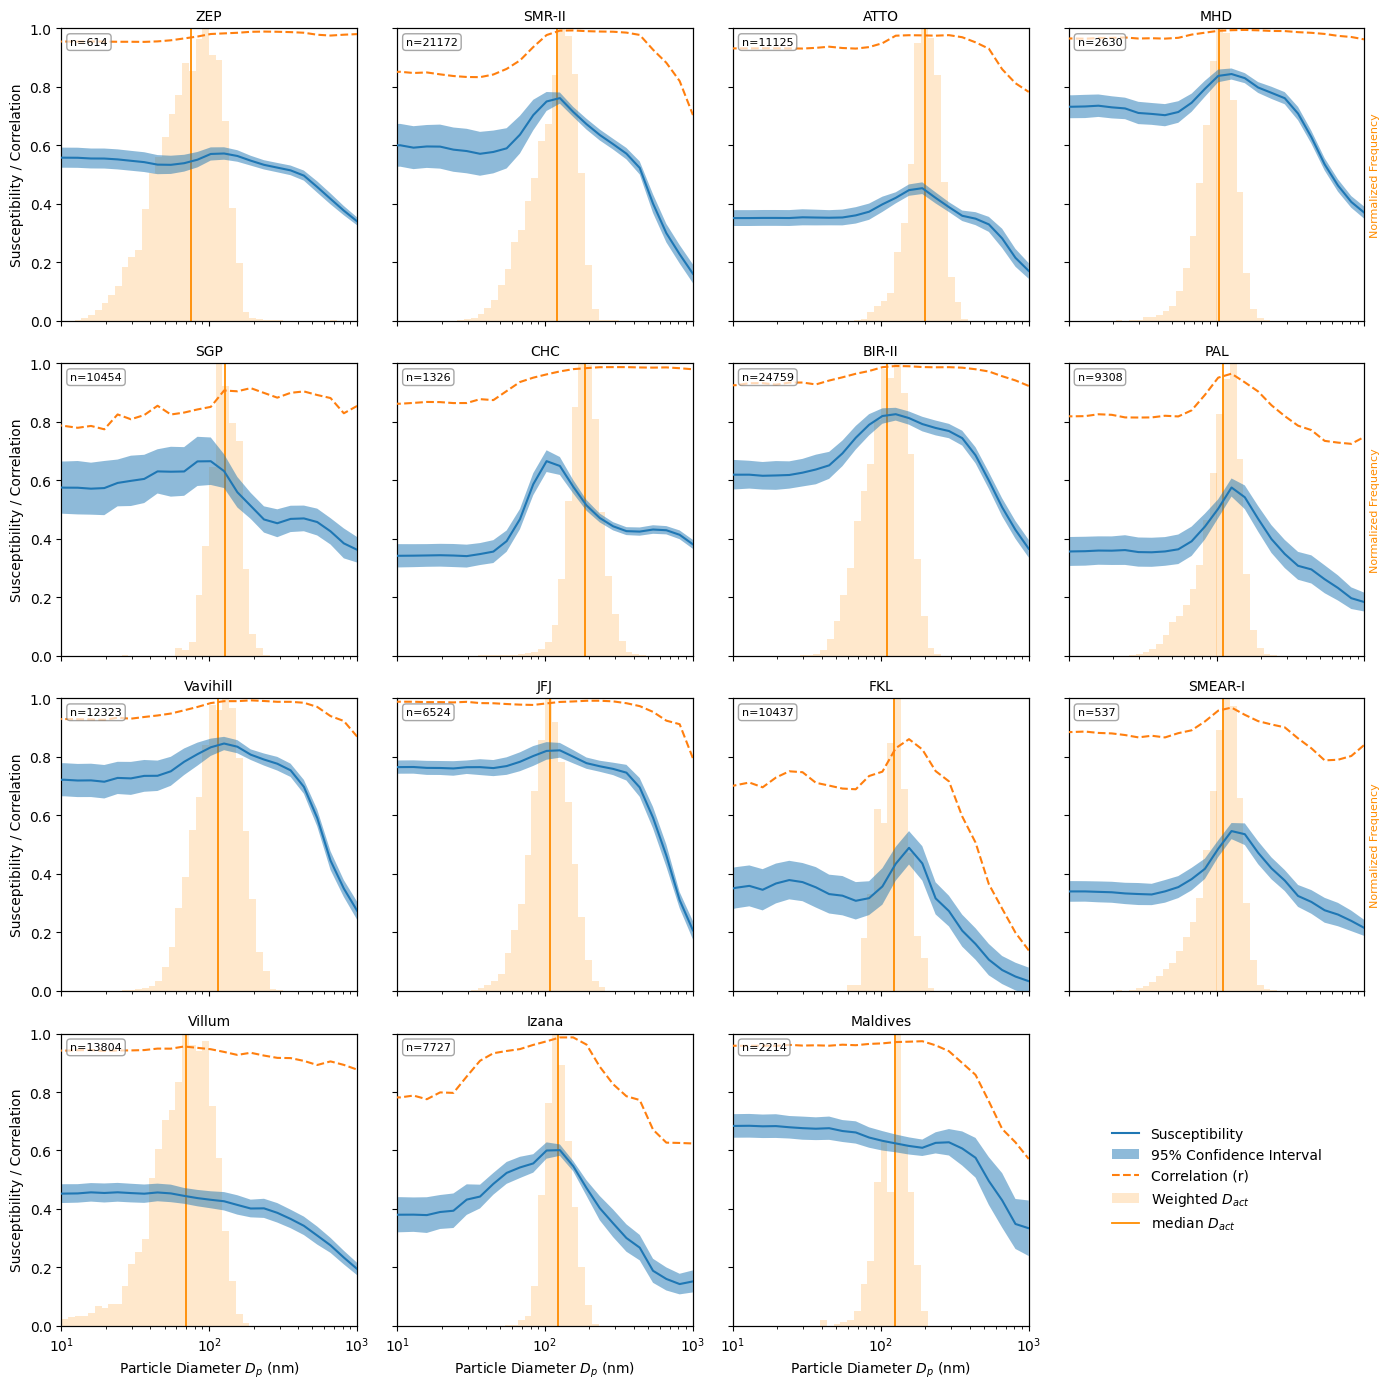

In [137]:
import numpy as np
reg_ds = xr.open_dataset('/share/pech2273/NorESM_Susceptibility_All_level.nc')
stations = reg_ds.station.values
n_stations = len(stations)

# shared log bins over the full x-range so every panel's overlay lines up
DACT_BINS = np.logspace(1, 3, 45)          # 1–1000 nm, matches ax.set_xlim
RADII = reg_ds['radius'].values
fig, axes = plt.subplots(4, 4, figsize=(14, 14), sharex=True, sharey=True)
axes = axes.flatten()

twins = []                                  # keep refs so we can share their y-scale
for i, station in enumerate(stations):
    ax = axes[i]

    slope   = reg_ds['slope'].sel(station=station)
    std_err = reg_ds['std_err'].sel(station=station)
    r_val   = reg_ds['r_value'].sel(station=station)

    ax.plot(RADII * 2, slope, label='Susceptibility', zorder=3)
    ax.fill_between(RADII * 2,
                    slope - 1.96 * std_err,
                    slope + 1.96 * std_err,
                    alpha=0.5, label='95% Confidence Interval', zorder=2)
    ax.plot(RADII * 2, r_val, '--', label='Correlation (r)', zorder=3)

    ax.set_title(station, fontsize=10)
    ax.set_xscale('log')
    ax.set_xlim([10, 1000])
    ax.set_ylim([0, 1])
    ax.text(0.03, 0.97, f"n={pos.size}",
                transform=ax.transAxes, va="top", ha="left", fontsize=8,
                bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.7))
    # --- overlay weighted activation-diameter distribution on a twin y-axis ---
    v = Dact_by_station.get(str(station))
    if v is not None and v.size:
        axd = ax.twinx()
        pos = v[v > 0]
        counts, edges = np.histogram(pos, bins=DACT_BINS)
        counts = counts / counts.max()          # normalize each panel to its own peak
        centers = np.sqrt(edges[:-1] * edges[1:])   # geometric centers (log bins)
        axd.bar(centers, counts, width=np.diff(edges),
                color='darkorange', alpha=0.20, zorder=0, align='center')
        axd.axvline(np.median(v), color='darkorange', ls='-', lw=1.3, zorder=1)
        axd.set_zorder(ax.get_zorder() - 1)
        ax.patch.set_visible(False)
        axd.set_xscale('log')
        axd.set_xlim([10, 1000])
        axd.set_ylim(0, 1)                        # same normalized scale everywhere
        axd.set_yticks([])                        # hide the count axis; it's now relative
        twins.append(axd)

# give all twin axes a common count scale so panels are comparable
if twins:
    ymax = max(t.get_ylim()[1] for t in twins)
    for k, t in enumerate(twins):
        t.set_ylim(0, ymax)
        # only label the count axis on the right-hand column to avoid clutter
        if (k := stations.tolist().index(t_station)) if False else True:
            pass
    for i, t in enumerate(twins):
        show = (i % 4 == 3)                    # rightmost column only
        t.set_ylabel('Normalized Frequency' if show else '', color='darkorange', fontsize=8)
        t.tick_params(axis='y', labelcolor='darkorange',
                      labelsize=7, length=(3 if show else 0),
                      labelright=show)

# --- Last panel used only for legend ---
legend_ax = axes[-1]
legend_ax.axis('off')
handles, labels = axes[0].get_legend_handles_labels()
# add the overlay entries to the legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
handles += [Patch(facecolor='darkorange', alpha=0.20, label='Weighted $D_{act}$'),
            Line2D([0], [0], color='darkorange', ls='-', lw=1.3, label='median $D_{act}$')]
labels  += ['Weighted $D_{act}$', 'median $D_{act}$']
legend_ax.legend(handles, labels, loc='center', frameon=False, fontsize=10)

for ax in axes[12:16]:
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')
for ax in axes[::4]:
    ax.set_ylabel('Susceptibility / Correlation')

plt.tight_layout()
plt.show()

In [138]:
# --- Sanity check: cloudy timesteps where EVERY mode falls outside the 1–99% band ---
# These are the FREQL>0.8 cells that yield an all-NaN weighted D_act (no mode
# survives the guard), i.e. the difference between "cloudy" and the per-panel n.
print(f"Cloudy (FREQL>{FREQL_THRESH}) cells with ALL modes outside "
      f"({FRAC_LO:.0f}, {FRAC_HI:.0f})% band:\n")
for st in ds["station"].values:
    dss = ds.sel(station=st)
    cloud = dss["FREQL"] > FREQL_THRESH

    any_mode_in_band = None
    for i in MODE_INDICES:
        f = dss[f"NACT_FRAC{i:02d}"]
        b = (f > FRAC_LO) & (f < FRAC_HI)
        any_mode_in_band = b if any_mode_in_band is None else (any_mode_in_band | b)

    bad = (cloud & ~any_mode_in_band).compute()   # cloudy but no mode in band
    n_cloud = int(cloud.compute().sum())
    n_bad   = int(bad.sum())
    pct     = 100 * n_bad / n_cloud if n_cloud else 0.0
    flag    = "  <-- present" if n_bad else ""
    print(f"{str(st):>12}: cloudy={n_cloud:>7d}  all_out_of_band={n_bad:>6d} "
          f"({pct:5.1f}%){flag}")

Cloudy (FREQL>0.8) cells with ALL modes outside (0, 100)% band:

         ZEP: cloudy=  21172  all_out_of_band=     0 (  0.0%)
      SMR-II: cloudy=  11125  all_out_of_band=     0 (  0.0%)
        ATTO: cloudy=   2630  all_out_of_band=     0 (  0.0%)
         MHD: cloudy=  10454  all_out_of_band=     0 (  0.0%)
         SGP: cloudy=   1326  all_out_of_band=     0 (  0.0%)
         CHC: cloudy=  24759  all_out_of_band=     0 (  0.0%)
      BIR-II: cloudy=   9308  all_out_of_band=     0 (  0.0%)
         PAL: cloudy=  12323  all_out_of_band=     0 (  0.0%)
    Vavihill: cloudy=   6524  all_out_of_band=     0 (  0.0%)
         JFJ: cloudy=  10437  all_out_of_band=     0 (  0.0%)
         FKL: cloudy=    537  all_out_of_band=     0 (  0.0%)
     SMEAR-I: cloudy=  13804  all_out_of_band=     0 (  0.0%)
      Villum: cloudy=   7727  all_out_of_band=     0 (  0.0%)
       Izana: cloudy=   2214  all_out_of_band=     0 (  0.0%)
    Maldives: cloudy=    614  all_out_of_band=     0 (  0.0%)
